In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import mesa

from model import SocialGPModel
from rewards import (
    sample_children_with_corr,
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    build_corr_matrix_option2,
    build_corr_matrix_option3,
    _min_max,
)
from tqdm import tqdm

In [6]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [7]:
rho_variants_raw = {
    "perfectly_calibrated":  np.array([1.0,  0.6,  0.0,  -0.6]), # beliefs match the true environment
    "sign_flipped":          np.array([1.0, -0.6,  0.0,  0.6]),  # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic":     np.array([1.0,  0.0,  0.0,  0.0]),  # ignores all social information
    "uniform_over_trusting": np.array([1.0,  0.6,  0.6,  0.6]),  # assumes everyone is positively aligned (over-generalization)
    "uniform_distrusting":   np.array([1.0, -0.6, -0.6,  -0.6]), # assumes everyone is anti-correlated (over-avoidance)
    "overconfident":         np.array([1.0,  0.9,  0.0,  -0.9]), # right signs, inflated strength; tests sensitivity to overconfidence
    "underconfident":        np.array([1.0,  0.2,  0.0,  -0.2]), # right signs, damped strength; tests robustness to weak beliefs
    "selective_trust":       np.array([1.0,  0.6,  0.0,  0.0]),  # trusts only the truly helpful peer; ignores the harmful one
    "selective_avoidance":   np.array([1.0,  0.0,  0.0,  -0.6]), # avoids only the harmful peer; ignores the helpful one
}

def project_rho_to_pd(rho_vec, max_norm=0.99):
    """Ensure the hub-correlation matrix stays PD by capping ‖rho_social‖₂."""
    rho_vec = np.asarray(rho_vec, dtype=float)
    social = rho_vec[1:]
    norm = np.linalg.norm(social)
    if norm >= max_norm and norm > 0:
        rho_vec[1:] = social * (max_norm / norm)
    return rho_vec

rho_variants = {name: project_rho_to_pd(v) for name, v in rho_variants_raw.items()}
rho_list = list(rho_variants.values())
rho_label_lookup = {tuple(v.round(6)): name for name, v in rho_variants.items()}

def label_rho(rho_arr):
    """Map a rho array to its scenario name; returns 'unknown' if not in the table."""
    key = tuple(np.asarray(rho_arr).round(6))  # tolerate float repr differences
    return rho_label_lookup.get(key, "unknown")

## Plot correlations

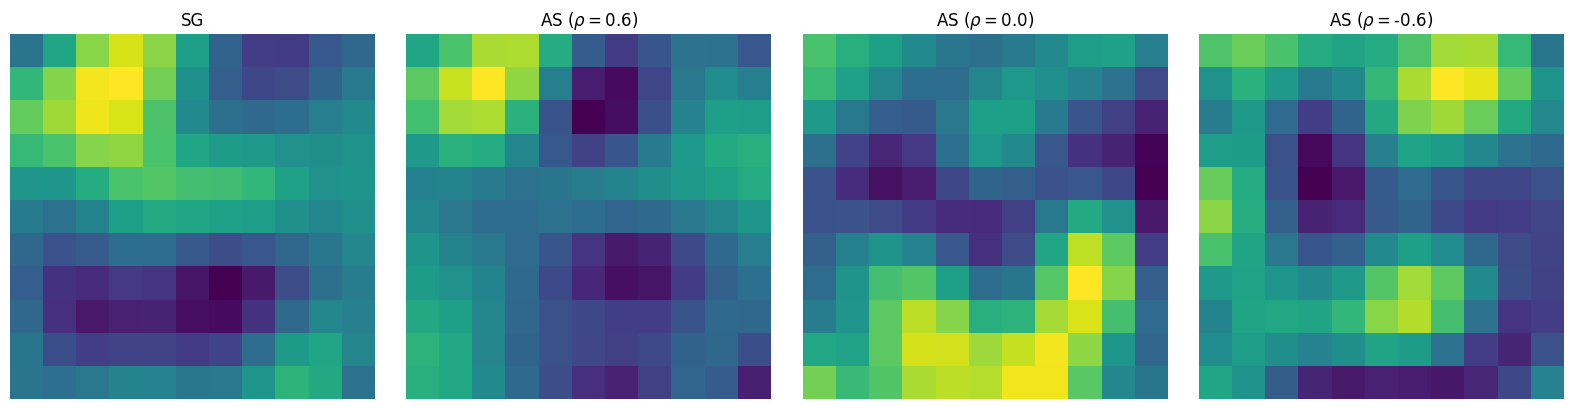

In [8]:
corr_matrix = build_corr_matrix_option1()  # parent + 3 children
n_children = corr_matrix.shape[0] - 1

seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 11 # change resolution
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

# keep reward scale consistent with other sims
child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

# parent
axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

# children
for _corr, c, ax in zip([0.6, 0.0, -0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho=${_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Run the model

In [9]:
m = SocialGPModel(
    n=n_children + 1,
    model_type="SG-ICM",
    child_maps=[parent] + child_maps,
    network_type="directed_one_to_four",
    rho=np.array([1.0, 0.6, 0.0, -0.6]),
    tau_sampling=True,  # tau=0.03
    beta_sampling=True,
    length_scale_sampling=True,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe()

results.head(20)

choice    reward  cumulative_reward model_type      tau  neg_log_likelihood  last_choice_distance_private  avg_choice_distance_private  nearest_choice_distance_private  last_choice_distance_social  avg_choice_distance_social  nearest_choice_distance_social
Step AgentID                                                                                                                                                                                                                                                                   
1    1         (2, 7) -0.839437          -0.839437     SG-ICM  0.01529        0.000000e+00                      0.000000                     0.000000                         0.000000                     0.000000                    0.000000                        0.000000
     2         (3, 0)  0.047518           0.047518         AS  0.01529        0.000000e+00                      0.000000                     0.000000                         0.000000                     0.000000                    0.000000                        0.000000
     3         (1, 1)  0.076333           0.076333         AS  0.01529        0.000000e+00                      0.000000                     0.000000                         0.000000                     0.000000                    0.000000                        0.000000
     4         (3, 6)  0.367625           0.367625         AS  0.01529        0.000000e+00                      0.000000                     0.000000                         0.000000                     0.000000                    0.000000                        0.000000
2    1         (6, 9)  0.610179          -0.229258     SG-ICM  0.01529        4.771254e+00                      4.472136                     4.472136                         4.472136                     7.721152                    7.721152                        4.242641
     2        (0, 10) -0.392744          -0.345226         AS  0.01529        4.787445e+00                     10.440307                    10.440307                        10.440307                     0.000000                    0.000000                        0.000000
     3         (0, 3)  0.379784           0.456118         AS  0.01529        4.787434e+00                      2.236068                     2.236068                         2.236068                     0.000000                    0.000000                        0.000000
     4        (3, 10) -0.320818           0.046807         AS  0.01529        4.787474e+00                      4.000000                     4.000000                         4.000000                     0.000000                    0.000000                        0.000000
3    1        (3, 10)  0.287911           0.058653     SG-ICM  0.01529        2.736629e-08                      3.162278                     3.162278                         3.162278                     3.538591                    5.639220                        0.000000
     2         (7, 8)  0.028600          -0.316626         AS  0.01529        4.779015e+00                      7.280110                     8.112191                         7.280110                     0.000000                    0.000000                        0.000000
     3         (0, 9) -0.038288           0.417830         AS  0.01529        4.779053e+00                      6.000000                     7.031129                         6.000000                     0.000000                    0.000000                        0.000000
     4         (5, 0)  0.333850           0.380657         AS  0.01529        4.779021e+00                     10.198039                     8.261297                         6.324555                     0.000000                    0.000000                        0.000000
4    1         (8, 3)  2.377415           2.436068     SG-ICM  0.01529        4.730601e+00                      8.602325                     7.379328                         6.324555                     6.44

In [10]:
R = build_corr_matrix_option1()

param_grid = {
    "n": 4,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "tau_sampling": True,
    "beta_sampling": True,
    "length_scale_sampling": True,
    "length_scale_is_identical": True,
    "seed": list(range(1000)),
    "network_type": "directed_one_to_four",
    "rho": rho_list,
    "corr_matrix": [R]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results = pd.DataFrame(batch_results)

  0%|          | 0/9000 [00:00<?, ?it/s]

In [11]:
batch_results = pd.DataFrame(batch_results)
batch_results['rho_label'] = batch_results['rho'].apply(label_rho)
batch_results.head()


,RunId,iteration,Step,n,model_type,observation_noise_private,observation_noise_social,tau_sampling,beta_sampling,length_scale_sampling,length_scale_is_identical,seed,network_type,rho,corr_matrix,avg_cumulative_reward,avg_reward,AgentID,choice,reward,cumulative_reward,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,rho_label
0,3,0,0,4,SG-ICM,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.5715767664977295, 0.5715767664977295, ...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.443456,0.443456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,uniform_over_trusting
1,3,0,1,4,SG-ICM,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.5715767664977295, 0.5715767664977295, ...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,1.0,"(9, 9)",0.654450,0.654450,0.01244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,uniform_over_trusting
2,3,0,1,4,AS,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.5715767664977295, 0.5715767664977295, ...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,2.0,"(5, 4)",0.561097,0.561097,0.01244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,uniform_over_trusting
3,3,0,1,4,AS,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.5715767664977295, 0.5715767664977295, ...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,3.0,"(9, 8)",0.327141,0.327141,0.01244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,uniform_over_trusting
4,3,0,1,4,AS,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, 0.5715767664977295, 0.5715767664977295, ...","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,4.0,"(3, 10)",0.231135,0.231135,0.01244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,uniform_over_trusting


In [12]:
def plot_reward(df, y_col="reward", keep_labels=None, figsize=(9, 5)):
    plot_df = df[df.model_type == "SG-ICM"].copy()
    if keep_labels:
        plot_df = plot_df[plot_df["rho_label"].isin(keep_labels)]
        hue_order = keep_labels
    else:
        hue_order = sorted(plot_df["rho_label"].unique())

    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=plot_df,
        x="Step",
        y=y_col,
        hue="rho_label",
        hue_order=hue_order,
        ax=ax,
    )
    ax.set_title(f"{y_col.replace('_', ' ').title()} under assumed task correlations")
    ax.set_xlabel("Step")
    ax.set_ylabel(y_col.replace("_", " ").title())
    ax.legend(
        title="Assumed correlation structure",
        bbox_to_anchor=(1.02, 0.5), loc="center left",
        borderaxespad=0,
    )
    plt.tight_layout()
    plt.show()

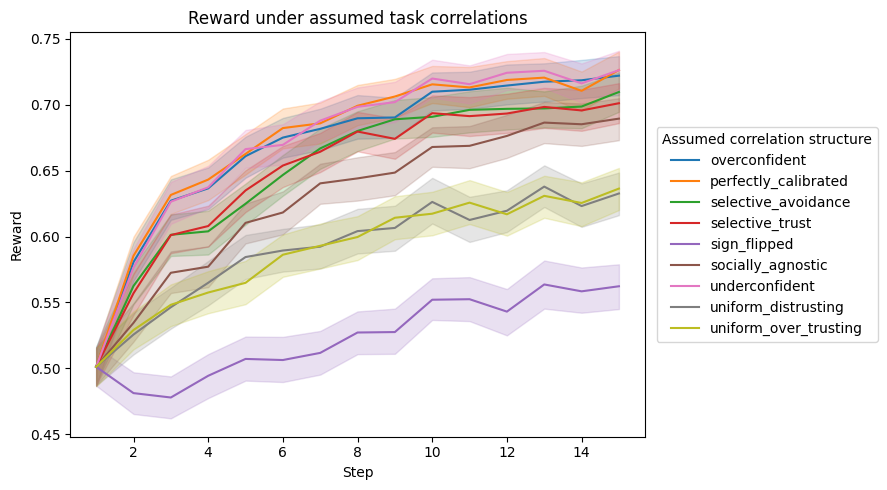

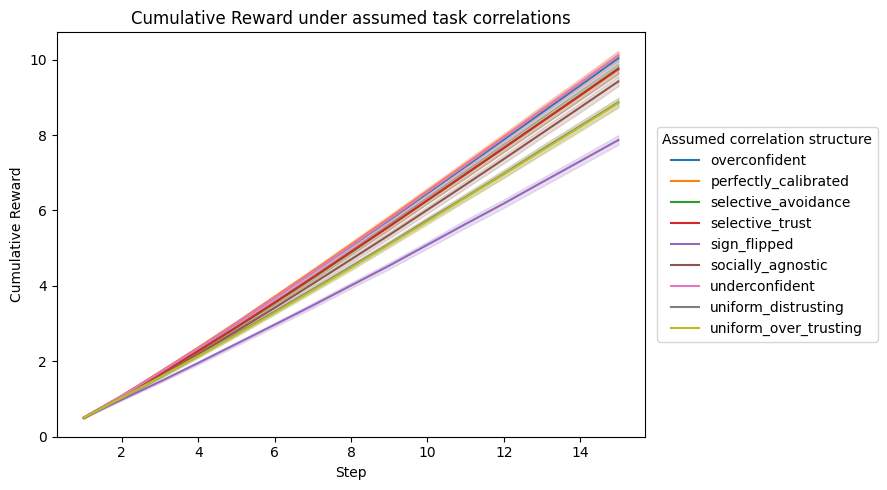

In [13]:
# All lines:
plot_reward(batch_results, y_col="reward")
plot_reward(batch_results, y_col="cumulative_reward")

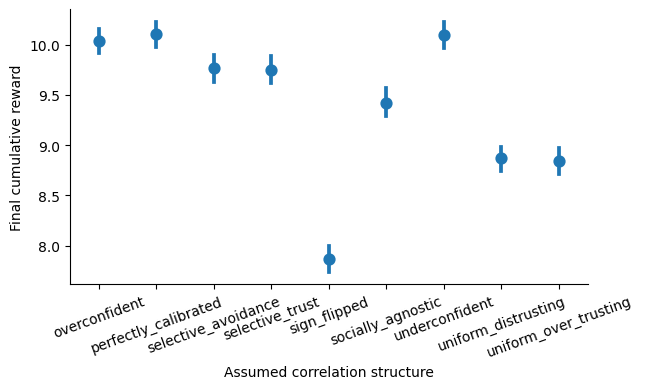

In [14]:
def plot_final_cumreward_catplot(df, x='rho_label'):
    plot_df = df[df.model_type == "SG-ICM"].copy()
    final_step = plot_df.groupby(['RunId', 'iteration'])['Step'].transform('max')
    last = plot_df[plot_df['Step'] == final_step].copy()

    sns.catplot(
        data=last,
        kind='point', # 'box',
        x=x,
        y='cumulative_reward',
        order=sorted(last[x].unique()),
        height=4,
        aspect=1.6,
        linestyle='none'
    )
    plt.xticks(rotation=20)
    plt.xlabel('Assumed correlation structure')
    plt.ylabel('Final cumulative reward')
    plt.tight_layout()
    plt.show()

plot_final_cumreward_catplot(batch_results)


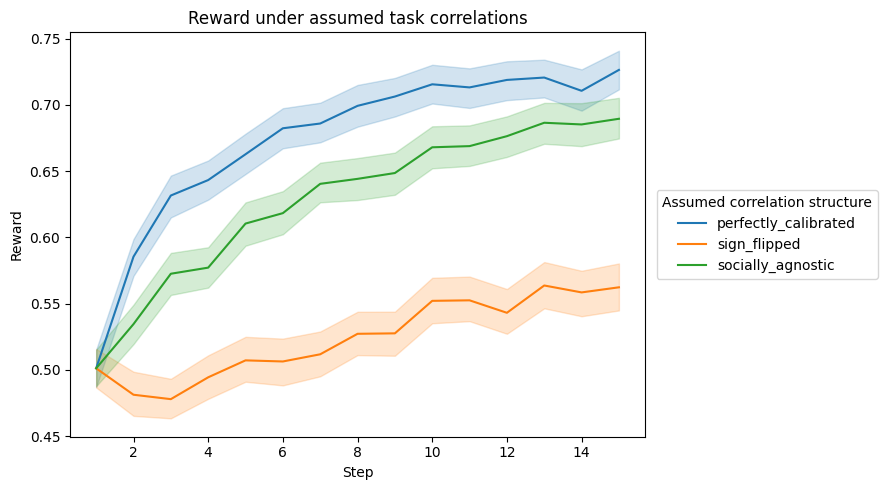

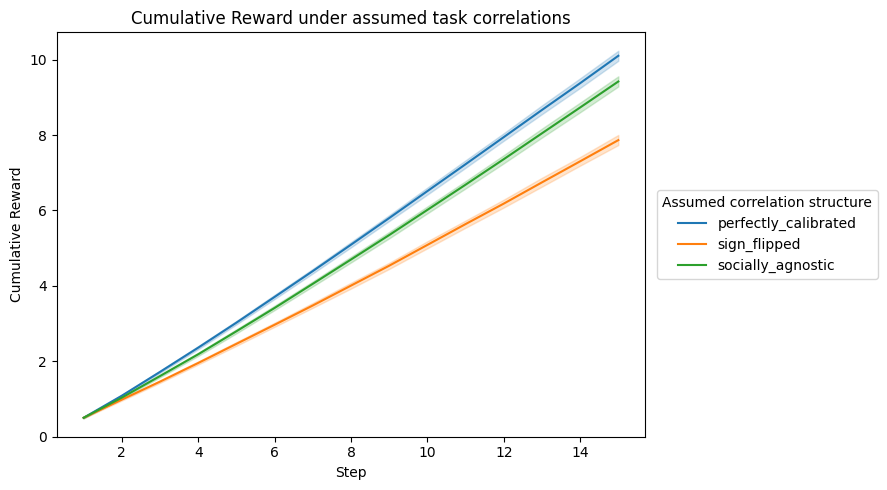

In [15]:
# Custom subset: 
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "sign_flipped",          # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic",     # ignores all social information
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

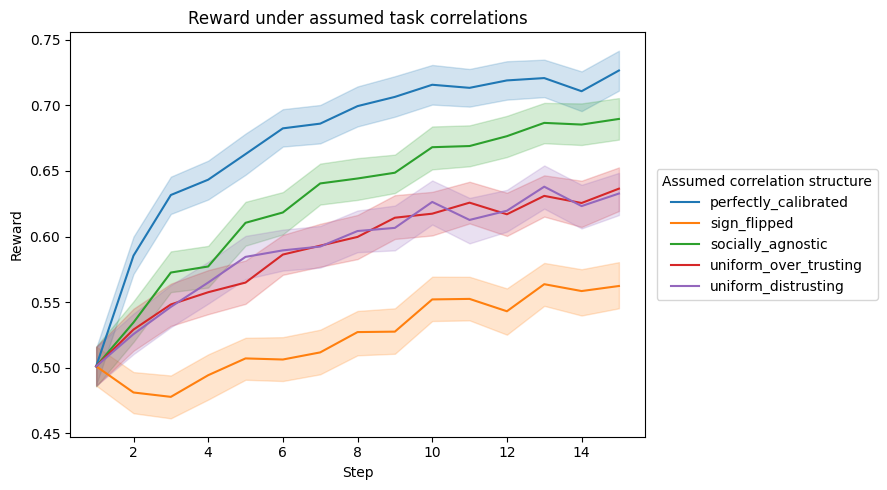

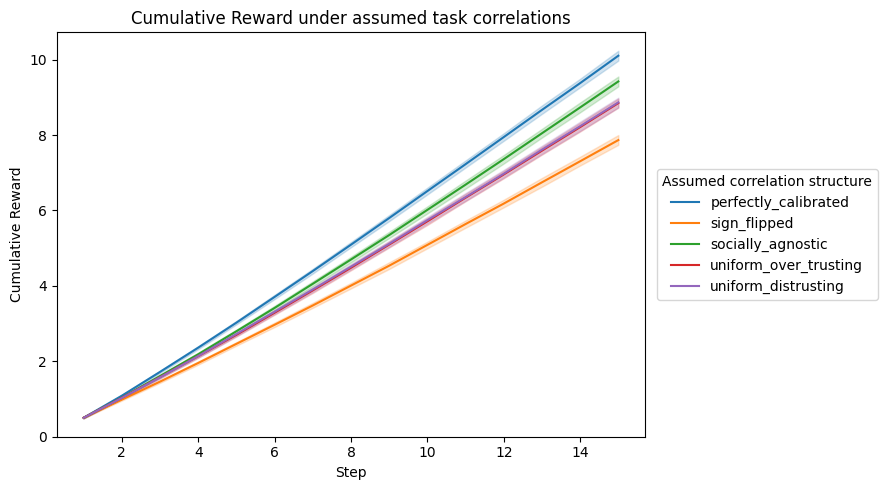

In [16]:
# Custom subset:
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "sign_flipped",          # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic",     # ignores all social information
    "uniform_over_trusting", # assumes everyone is positively aligned (over-generalization) 
    "uniform_distrusting"    # assumes everyone is anti-correlated (over-avoidance)
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

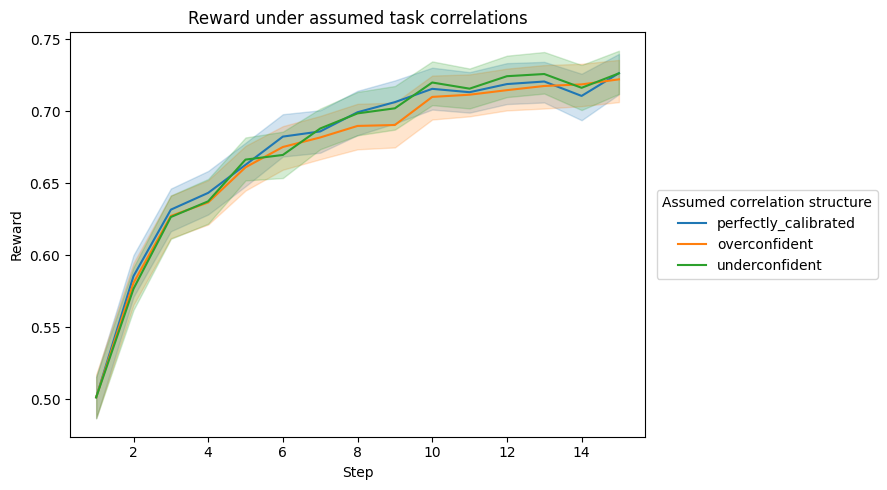

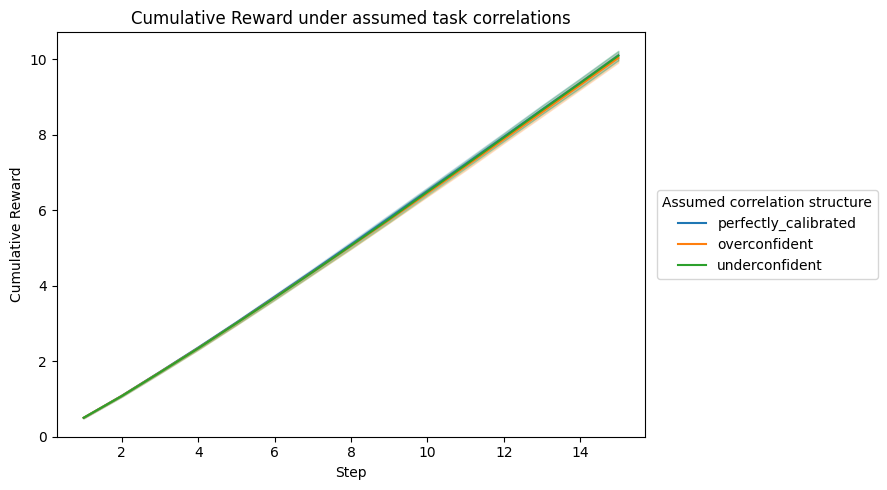

In [17]:
# Custom subset: knows who to trust or distrust, but the magnitude is not corect
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "overconfident",          # right signs, inflated strength; tests sensitivity to overconfidence
    "underconfident",         # right signs, damped strength; tests robustness to weak beliefs
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

# “aligned vs sign-flipped vs agnostic” to highlight correctness of belief.

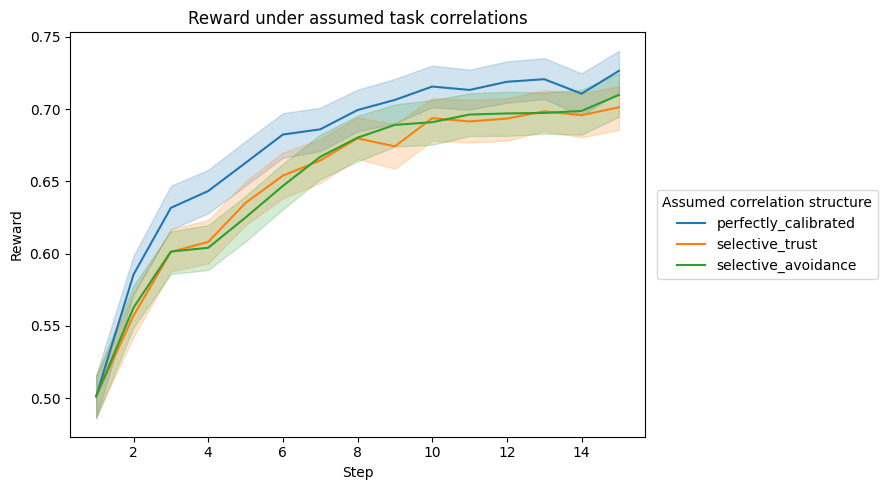

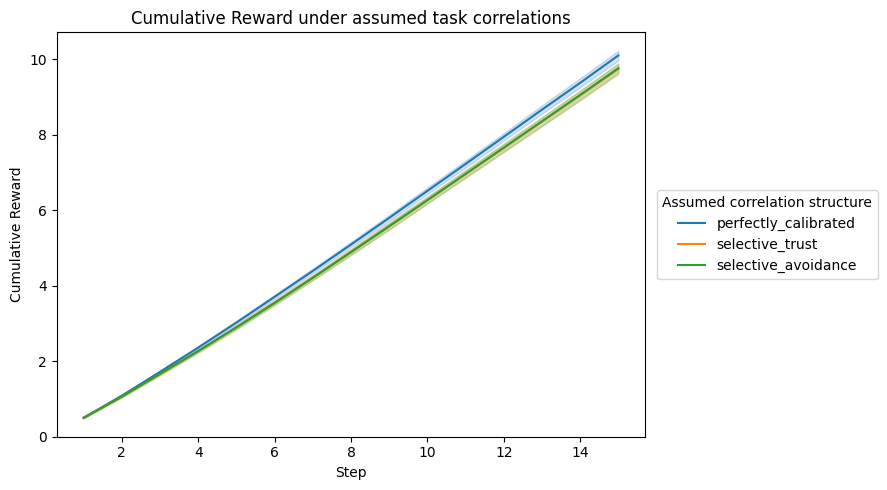

In [18]:
# Custom subset: [trust/distrust] the correct person, and ignore the one that should be [distrust/trust]
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "selective_trust",        # trusts only the truly helpful peer; ignores the harmful one
    "selective_avoidance"    # avoids only the harmful peer; ignores the helpful one
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

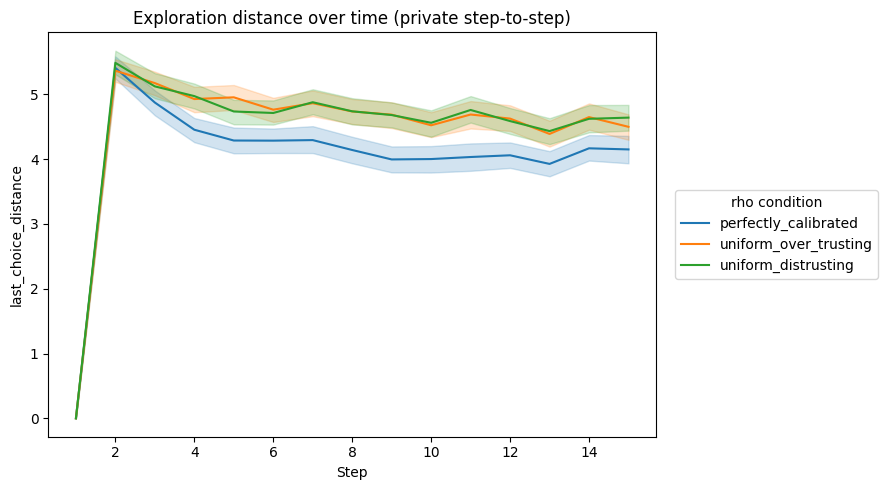

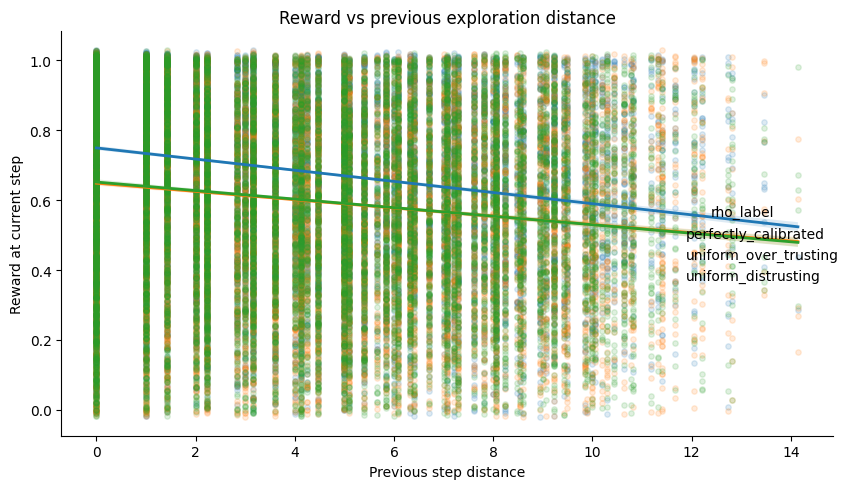

perfectly_calibrated slope(prev_dist_priv→reward)= -0.015970866251547908 intercept= 0.7496793316548056
uniform_over_trusting slope(prev_dist_priv→reward)= -0.011828091887715038 intercept= 0.6488053575082945
uniform_distrusting slope(prev_dist_priv→reward)= -0.01221885905365394 intercept= 0.6519505996167614


In [19]:
from sklearn.linear_model import LinearRegression

# choose which rho conditions to analyze
keep_labels = ["perfectly_calibrated", "uniform_over_trusting", "uniform_distrusting"]

required_cols = [
    "last_choice_distance_private",
    "last_choice_distance_social",
    "reward",
    "Step",
    "rho_label",
    "model_type",
]

df = batch_results.copy()
df = df[(df["model_type"] == "SG-ICM") & (df["rho_label"].isin(keep_labels))].copy()
group_cols = [c for c in ["RunId", "iteration", "AgentID"] if c in df.columns]
df = df.sort_values(group_cols + ["Step"])

# distance at t-1 predicts reward at t
df["prev_dist_priv"] = df.groupby(group_cols)["last_choice_distance_private"].shift(1)
df["prev_dist_soc"] = df.groupby(group_cols)["last_choice_distance_social"].shift(1)

df_lag = df.dropna(subset=["prev_dist_priv", "reward"]).copy()

# Distance over time
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df,
    x="Step",
    y="last_choice_distance_private",
    hue="rho_label",
    hue_order=keep_labels,
    errorbar="ci",
)
plt.title("Exploration distance over time (private step-to-step)")
plt.xlabel("Step")
plt.ylabel("last_choice_distance")
plt.legend(title="rho condition", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# Reward vs previous distance
g = sns.lmplot(
    data=df_lag,
    x="prev_dist_priv",
    y="reward",
    hue="rho_label",
    hue_order=keep_labels,
    height=5,
    aspect=1.3,
    scatter_kws={"alpha": 0.15, "s": 15},
    line_kws={"linewidth": 2},
)
g.set_axis_labels("Previous step distance", "Reward at current step")
plt.title("Reward vs previous exploration distance")
plt.tight_layout()
plt.show()

for label in keep_labels:
    sub = df_lag[df_lag["rho_label"] == label]
    X = sub[["prev_dist_priv"]].to_numpy()
    y = sub["reward"].to_numpy()
    lr = LinearRegression().fit(X, y)
    print(label, "slope(prev_dist_priv→reward)=", float(lr.coef_[0]), "intercept=", float(lr.intercept_))


## Explore $\rho$ Magnitude Sensitivity

In [20]:
rho_list_2_agents = [
    np.array([1.0,  np.round(i, 2)])
     for i in np.linspace(-0.95, 0.95, 39)
]

rho_list_2_agents[-2:]

[array([1. , 0.9]), array([1.  , 0.95])]

In [21]:
param_grid = {
    "n": 2,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "tau_sampling": True,
    "beta_sampling": True,
    "length_scale_sampling": True,
    "length_scale_is_identical": True,
    "seed": list(range(2000)),
    "network_type": "directed_one_to_four",
    "rho": rho_list_2_agents,
    "corr_matrix": [np.array([[1.0, 0.6], [0.6, 1.0]]),
                    np.array([[1.0, -0.6], [-0.6, 1.0]])]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results = pd.DataFrame(batch_results)

  0%|          | 0/156000 [00:00<?, ?it/s]

Process SpawnPoolWorker-14:
Process SpawnPoolWorker-11:
Process SpawnPoolWorker-12:
Process SpawnPoolWorker-13:
Process SpawnPoolWorker-10:
Process SpawnPoolWorker-9:
Process SpawnPoolWorker-15:
Traceback (most recent call last):
Process SpawnPoolWorker-16:
  File "/Users/leeliang/.pyenv/versions/3.12.12/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/leeliang/.pyenv/versions/3.12.12/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/leeliang/.pyenv/versions/3.12.12/lib/python3.12/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ^^^^^^^^^^^^^^^^^^^
  File "/Users/leeliang/Desktop/0HMC/CogSci2026/Spatial-MAB-ABM/.venv/lib/python3.12/site-packages/mesa/batchrunner.py", line 175, in _model_run_func
    model.step()
  File "/Users/leeliang/Desktop/0HMC/CogSci2026/Spatial-MAB-ABM/.venv/lib/python3.12/site-packages/

KeyboardInterrupt: 

In [ ]:
mask = (batch_results.Step == 15) & (batch_results.model_type == "SG-ICM")
rho_sensitivity_df = batch_results[mask].reset_index()
rho_sensitivity_df['rho_value'] = [v[1] for v in rho_sensitivity_df['rho'].values]
rho_sensitivity_df['corr_value'] = [v[0, 1] for v in rho_sensitivity_df['corr_matrix'].values]

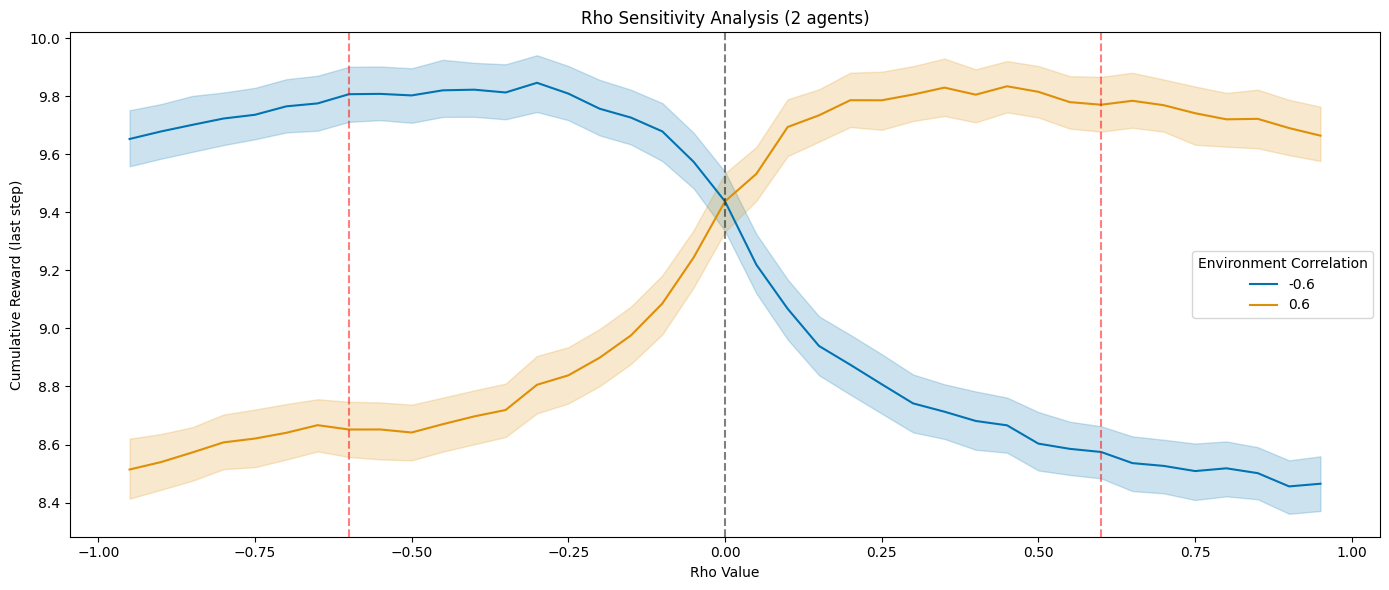

In [ ]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=rho_sensitivity_df,
    x="rho_value",
    y="cumulative_reward",
    hue="corr_value",
    palette=sns.color_palette("colorblind", 2),
)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)

for val in [-0.6, 0.6]:
    plt.axvline(x=val, color='red', linestyle='--', alpha=0.5)



plt.title("Rho Sensitivity Analysis (2 agents)")
plt.xlabel("Rho Value")
plt.ylabel("Cumulative Reward (last step)")
plt.legend(title="Environment Correlation")

plt.tight_layout()
plt.show()

## Parameter Sensitivity (tau, beta, lambda effects on rho learning)

In [31]:
# tau
tau_values = np.linspace(0.005, 0.05, 10)

param_grid_tau = {
    "n": 2,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "tau_sampling": False,  # Disable sampling, use explicit values
    "tau": list(tau_values),  # Explicit tau range
    "beta_sampling": True,  # Keep beta random
    "length_scale_sampling": True,
    "length_scale_is_identical": True,
    "seed": list(range(500)),  # Moderate sample size
    "network_type": "directed_one_to_four",
    "rho": rho_list_2_agents,
    "corr_matrix": [
        np.array([[1.0, 0.6], [0.6, 1.0]]),   # Positively correlated peer
        np.array([[1.0, -0.6], [-0.6, 1.0]])  # Anti-correlated peer
    ]
}

batch_results_tau = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid_tau,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results_tau = pd.DataFrame(batch_results_tau)
batch_results_tau['rho_value'] = [v[1] for v in batch_results_tau['rho'].values]
batch_results_tau['corr_value'] = [v[0, 1] for v in batch_results_tau['corr_matrix'].values]


# Analyze tau effect: cumulative reward by tau and rho
mask = (batch_results_tau.Step == 15) & (batch_results_tau.model_type == "SG-ICM")
tau_sensitivity_df = batch_results_tau[mask].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Cumulative reward vs rho value, colored by tau
for corr in [0.6, -0.6]:
    sub = tau_sensitivity_df[tau_sensitivity_df['corr_value'] == corr].copy()
    ax = axes[0 if corr == 0.6 else 1]

    sns.lineplot(
        data=sub,
        x="rho_value",
        y="cumulative_reward",
        hue="tau",
        palette="viridis",
        ax=ax,
        errorbar="ci",
    )

    ax.axvline(x=corr, color='red', linestyle='--', alpha=0.5, label='Ground truth ρ')
    ax.set_title(f"Tau Sensitivity (Ground truth ρ={corr})")
    ax.set_xlabel("Assumed ρ value")
    ax.set_ylabel("Final Cumulative Reward")
    ax.legend(title="τ (temperature)", bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)

plt.tight_layout()
plt.show()

  0%|          | 0/390000 [00:00<?, ?it/s]

Process SpawnPoolWorker-35:
Process SpawnPoolWorker-38:
Process SpawnPoolWorker-37:


KeyboardInterrupt: 

In [ ]:
# beta
beta_values = np.linspace(0.1, 2.0, 10)

param_grid_beta = {
    "n": 2,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "tau_sampling": True,  # Keep tau random
    "beta_sampling": False,  # Disable sampling, use explicit values
    "beta": list(beta_values),  # Explicit beta range
    "length_scale_sampling": True,
    "length_scale_is_identical": True,
    "seed": list(range(500)),
    "network_type": "directed_one_to_four",
    "rho": rho_list_2_agents,
    "corr_matrix": [
        np.array([[1.0, 0.6], [0.6, 1.0]]),
        np.array([[1.0, -0.6], [-0.6, 1.0]])
    ]
}

batch_results_beta = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid_beta,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results_beta = pd.DataFrame(batch_results_beta)
batch_results_beta['rho_value'] = [v[1] for v in batch_results_beta['rho'].values]
batch_results_beta['corr_value'] = [v[0, 1] for v in batch_results_beta['corr_matrix'].values]

# Analyze beta effect
mask = (batch_results_beta.Step == 15) & (batch_results_beta.model_type == "SG-ICM")
beta_sensitivity_df = batch_results_beta[mask].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for corr in [0.6, -0.6]:
    sub = beta_sensitivity_df[beta_sensitivity_df['corr_value'] == corr].copy()
    ax = axes[0 if corr == 0.6 else 1]

    sns.lineplot(
        data=sub,
        x="rho_value",
        y="cumulative_reward",
        hue="beta",
        palette="plasma",
        ax=ax,
        errorbar="ci",
    )

    ax.axvline(x=corr, color='red', linestyle='--', alpha=0.5, label='Ground truth ρ')
    ax.set_title(f"Beta Sensitivity (Ground truth ρ={corr})")
    ax.set_xlabel("Assumed ρ value")
    ax.set_ylabel("Final Cumulative Reward")
    ax.legend(title="β (exploration)", bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)

plt.tight_layout()
plt.show()


## Grid Size Effect test

In [23]:
# Test whether larger grid sizes improve:
# 1. Environment correlation accuracy (how well generated environments match target correlations)
# 2. Agent performance (cumulative reward)

R = build_corr_matrix_option1()
param_grid = {
    "n": 4,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "tau_sampling": True,
    "beta_sampling": True,
    "length_scale_sampling": True,
    "length_scale_is_identical": True,
    "seed": list(range(200)),  # Use fewer seeds to keep runtime reasonable
    "network_type": "directed_one_to_four",
    "rho": [np.array([1.0, 0.6, 0.0, -0.6])],  # Only perfectly calibrated for clarity
    "corr_matrix": [R],
    "grid_size": [11, 21, 31]  # Test different grid sizes
}

batch_results_grid = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results_grid = pd.DataFrame(batch_results_grid)
batch_results_grid['grid_size_label'] = batch_results_grid['grid_size'].apply(lambda x: f'{x}x{x}')
batch_results_grid.head()

  0%|          | 0/600 [00:00<?, ?it/s]

,RunId,iteration,Step,n,model_type,observation_noise_private,observation_noise_social,tau_sampling,beta_sampling,length_scale_sampling,length_scale_is_identical,seed,network_type,rho,corr_matrix,grid_size,avg_cumulative_reward,avg_reward,AgentID,choice,reward,cumulative_reward,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,grid_size_label
0,4,0,0,4,SG-ICM,0.0001,0.0001,True,True,True,True,1,directed_one_to_four,"[1.0, 0.6, 0.0, -0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",21,0.619834,0.619834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21x21
1,4,0,1,4,SG-ICM,0.0001,0.0001,True,True,True,True,1,directed_one_to_four,"[1.0, 0.6, 0.0, -0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",21,1.034134,0.517067,1.0,"(5, 3)",0.646736,0.646736,0.015162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21x21
2,4,0,1,4,AS,0.0001,0.0001,True,True,True,True,1,directed_one_to_four,"[1.0, 0.6, 0.0, -0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",21,1.034134,0.517067,2.0,"(18, 13)",0.613498,0.613498,0.015162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21x21
3,4,0,1,4,AS,0.0001,0.0001,True,True,True,True,1,directed_one_to_four,"[1.0, 0.6, 0.0, -0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",21,1.034134,0.517067,3.0,"(13, 20)",0.532368,0.532368,0.015162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21x21
4,4,0,1,4,AS,0.0001,0.0001,True,True,True,True,1,directed_one_to_four,"[1.0, 0.6, 0.0, -0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",21,1.034134,0.517067,4.0,"(11, 19)",0.686732,0.686732,0.015162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21x21


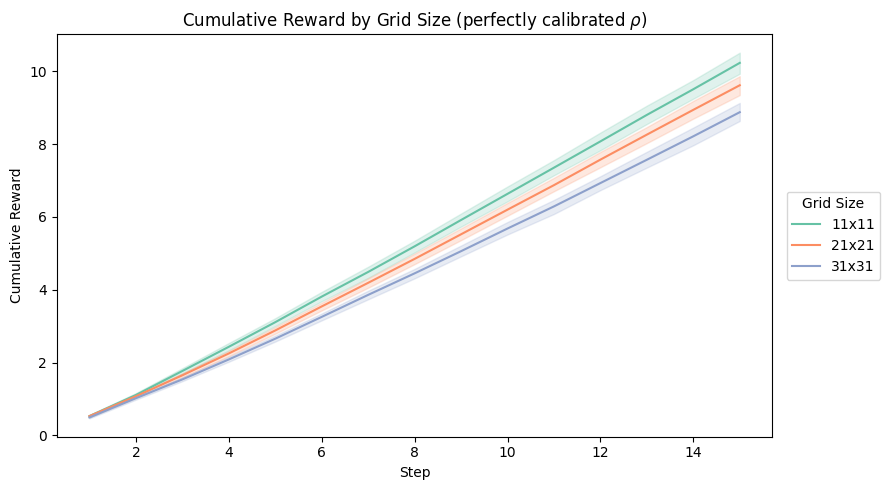

In [24]:
# Plot cumulative reward by grid size
plot_df = batch_results_grid[batch_results_grid.model_type == "SG-ICM"].copy()

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=plot_df,
    x="Step",
    y="cumulative_reward",
    hue="grid_size_label",
    hue_order=['11x11', '21x21', '31x31'],
    ax=ax,
    palette='Set2'
)
ax.set_title("Cumulative Reward by Grid Size (perfectly calibrated $\\rho$)")
ax.set_xlabel("Step")
ax.set_ylabel("Cumulative Reward")
ax.legend(
    title="Grid Size",
    bbox_to_anchor=(1.02, 0.5), loc="center left",
    borderaxespad=0,
)
plt.tight_layout()
plt.show()

/var/folders/jb/dqyqqwzs7s335q1r73w5cpg00000gn/T/ipykernel_82979/2227354320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


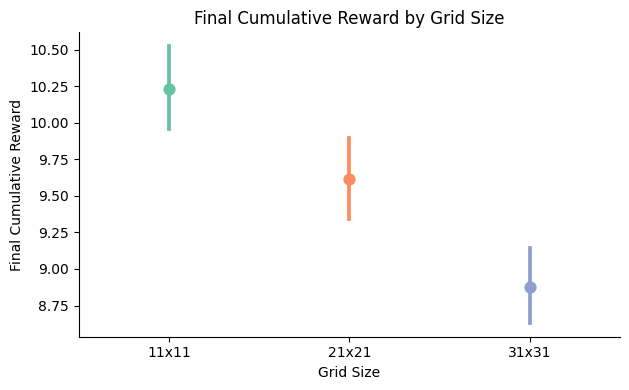

In [35]:
# Plot final cumulative reward comparison
plot_df = batch_results_grid[batch_results_grid.model_type == "SG-ICM"].copy()
final_step = plot_df.groupby(['RunId', 'iteration'])['Step'].transform('max')
last = plot_df[plot_df['Step'] == final_step].copy()

sns.catplot(
    data=last,
    kind='point',
    x='grid_size_label',
    y='cumulative_reward',
    order=['11x11', '21x21', '31x31'],
    height=4,
    aspect=1.6,
    linestyle='none',
    palette='Set2'
)
plt.xlabel('Grid Size')
plt.ylabel('Final Cumulative Reward')
plt.title('Final Cumulative Reward by Grid Size')
plt.tight_layout()
plt.show()

/var/folders/jb/dqyqqwzs7s335q1r73w5cpg00000gn/T/ipykernel_82979/1680113896.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/jb/dqyqqwzs7s335q1r73w5cpg00000gn/T/ipykernel_82979/1680113896.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


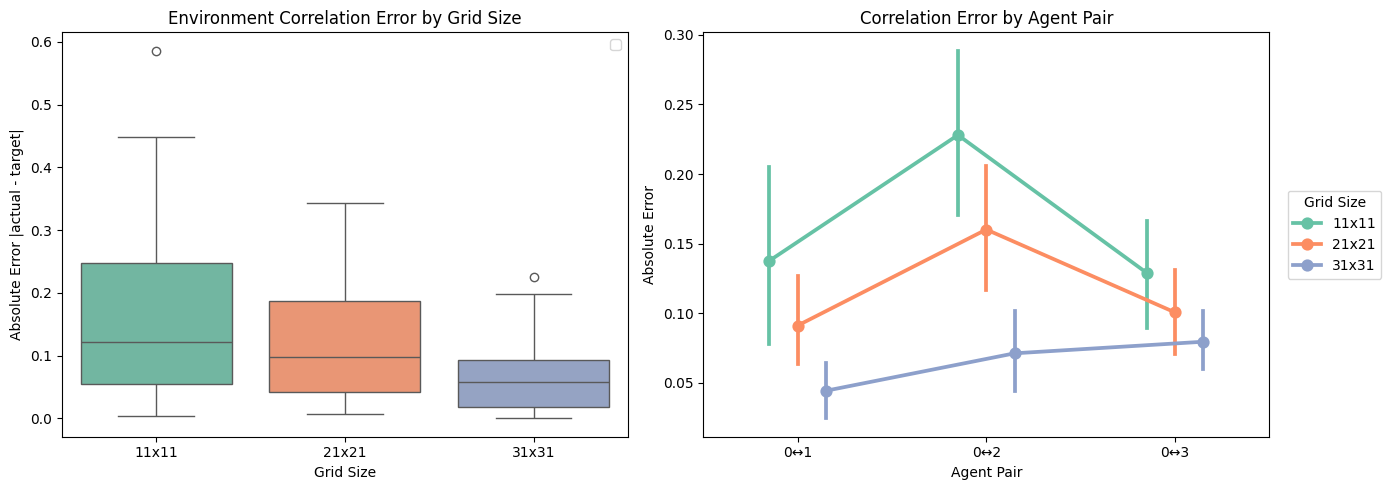

In [33]:
# Visualize environment correlation accuracy by grid size
def measure_env_correlations(grid_size, corr_matrix, n_seeds=20):
    """Measure actual correlations in generated environments."""
    results = []

    for seed in range(n_seeds):
        a_rng = np.random.default_rng(seed)
        parent, child_maps = make_parent_and_children_cholesky2(
            rng=a_rng,
            grid_size=grid_size,
            n_children=corr_matrix.shape[0],
            length_scale=2.0,
            corr_matrix=corr_matrix,
        )

        child_maps = [_min_max(c) - 0.5 for c in [parent] + child_maps]
        flat_maps = [c.ravel() for c in child_maps]
        R_actual = np.corrcoef(flat_maps)

        # Store agent 0's correlations
        for j in range(1, corr_matrix.shape[0]):
            results.append({
                'grid_size': f'{grid_size}x{grid_size}',
                'agent_pair': f'0↔{j}',
                'target': corr_matrix[0, j],
                'actual': R_actual[0, j],
                'error': abs(R_actual[0, j] - corr_matrix[0, j])
            })

    return pd.DataFrame(results)

R = build_corr_matrix_option1()
corr_results = pd.concat([
    measure_env_correlations(size, R, n_seeds=20)
    for size in [11, 21, 31]
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error distribution
sns.boxplot(
    data=corr_results,
    x='grid_size',
    y='error',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Environment Correlation Error by Grid Size')
axes[0].set_xlabel('Grid Size')
axes[0].set_ylabel('Absolute Error |actual - target|')
# axes[0].axhline(y=0.15, color='red', linestyle='--', alpha=0.5, label='Tolerance')
axes[0].legend()

# Plot 2: Error by agent pair
sns.pointplot(
    data=corr_results,
    x='agent_pair',
    y='error',
    hue='grid_size',
    hue_order=['11x11', '21x21', '31x31'],
    ax=axes[1],
    dodge=0.3,
    palette='Set2'
)
axes[1].set_title('Correlation Error by Agent Pair')
axes[1].set_xlabel('Agent Pair')
axes[1].set_ylabel('Absolute Error')
# axes[1].axhline(y=0.15, color='red', linestyle='--', alpha=0.5)
axes[1].legend(title='Grid Size', bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.tight_layout()
plt.show()